In [88]:
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
%pwd

'/Users/peiyuliu/Desktop/PKU-Undergraduate-Course-Public/生物化学实验(Biochemistry Lab)/Week 6/20241018'

In [90]:
data = pd.read_csv('Desalting-Group5+6-AKTA-20241018.csv', header=None)

In [91]:
data = data[2:].reset_index(drop=True)
data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,ml,mAU,ml,mS/cm,ml,%B,ml,ml/min,ml,MPa,ml,Fraction,ml,Injection,ml,Logbook,NaN
1,0.001,344.9079,0.001,0.27,0.001,0,0.001,1,0.001,0,52.2231,T1,6.0168,NaN,0,Manual Run 10/18/2024 1:57:23 PM +08:00 Result...,NaN
2,0.008,344.93,0.008,0.27,0.008,0,0.008,1,0.008,0,52.7232,T2,NaN,NaN,0,Instrument information:SystemName = ( 00000000...,NaN
3,0.015,344.9494,0.015,0.27,0.015,0,0.015,1,0.015,0,53.7267,T3,NaN,NaN,0,SampleValve Buffer,NaN
4,0.022,344.97,0.022,0.27,0.022,0,0.022,1,0.022,0,54.7303,T4,NaN,NaN,0,Fractionation\Peak collection stopped,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8488,59.351,190.05,59.351,2.64,59.351,0,59.351,1,59.351,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8489,59.358,190.05,59.358,2.64,59.358,0,59.358,1,59.358,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8490,59.365,190.05,59.365,2.64,59.365,0,59.365,1,59.365,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8491,59.372,190.05,59.372,2.64,59.372,0,59.372,1,59.372,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
data = data.drop(columns=[2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
data.columns = data.iloc[0]
data = data.iloc[1:]
data.set_index('ml', inplace=True) 
display(data)

,mAU,mS/cm,%B
ml,,,
0.001,344.9079,0.27,0
0.008,344.93,0.27,0
0.015,344.9494,0.27,0
0.022,344.97,0.27,0
0.029,344.9866,0.27,0
...,...,...,...
59.351,190.05,2.64,0
59.358,190.05,2.64,0
59.365,190.05,2.64,0


In [93]:
data = data.reset_index()
data = data.apply(pd.to_numeric, errors='coerce')
data.set_index('ml', inplace=True)

In [94]:
display(data)

,mAU,mS/cm,%B
ml,,,
0.001,344.9079,0.27,0
0.008,344.9300,0.27,0
0.015,344.9494,0.27,0
0.022,344.9700,0.27,0
0.029,344.9866,0.27,0
...,...,...,...
59.351,190.0500,2.64,0
59.358,190.0500,2.64,0
59.365,190.0500,2.64,0


In [95]:
data = data.iloc[:-1]

In [96]:
data.rename(columns={'mAU': 'UV(mAU)', 'mS/cm': 'Conductivity(mS/cm)'}, inplace=True)

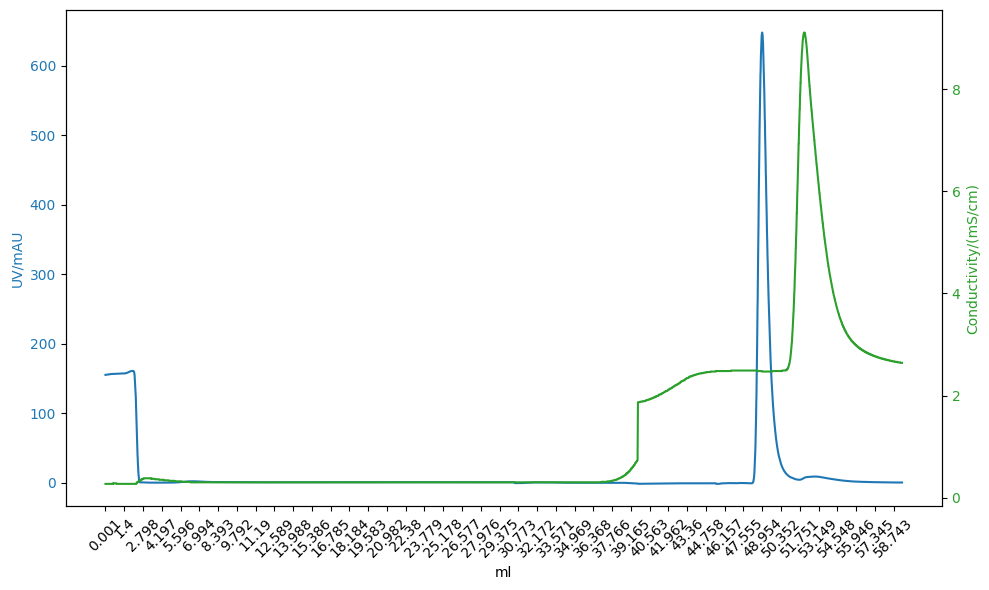

In [97]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(data.index, data['UV(mAU)'] - 190, color='tab:blue', label='UV/mAU')
ax1.set_xlabel('ml')
ax1.set_ylabel('UV/mAU', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()
ax2.plot(data.index, data['Conductivity(mS/cm)'], color='tab:green', label='Conductivity/(mS/cm)')
ax2.set_ylabel('Conductivity/(mS/cm)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

ax1.set_xticks(data.index[::200])
ax1.set_xticklabels(data.index[::200], rotation=45)
fig.tight_layout()
plt.savefig("./fig2.svg", format='svg')
plt.show()
